<a href="https://colab.research.google.com/github/songnee/test/blob/main/1_SimpleLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simple Linear Regression (단순 선형 회귀)

<img src="https://velog.velcdn.com/images/newnew_daddy/post/e4005869-3882-4019-9a5e-9c89d79f042d/image.png" width=80%>

#### 1. 개념
- **정의** : 단순 선형 회귀는 하나의 독립 변수와 하나의 종속 변수 간의 관계를 모델링하는 회귀 분석 방법
- **목적** : 독립 변수의 값에 따라 종속 변수의 값을 예측하고, 두 변수 간의 선형 관계를 파악
- **사용 상황** : 독립 변수(입력 변수)와 종속 변수(출력 변수) 간의 관계가 선형(직선)으로 나타날 때 사용. 즉, 독립 변수의 변화에 따라 종속 변수가 비례적으로 변한다고 가정할 수 있는 경우
- **예시**
  - 집의 크기와 가격 간의 관계를 분석할 때, 크기가 커질수록 가격이 비례적으로 증가하는 경우.
  - 직장에서의 근무 연수와 연봉 간의 관계를 분석할 때, 연수가 늘어날수록 연봉이 일정 비율로 증가하는 경우.

#### 2. 수학적 표현식
$$y = \beta_0 + \beta_1x + \epsilon$$

#### 3. 특징
- **선형성**: 독립 변수와 종속 변수 간의 관계가 선형으로 가정됨.
- **단순성**: 모델이 매우 단순하며 해석이 용이함.
- **한계**: 독립 변수와 종속 변수 간의 관계가 비선형일 경우 적합하지 않음.

#### 1. 데이터 Load

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

matplotlib.rc('font', family='AppleGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

In [ ]:
df = pd.read_csv('./dataset/Salary_Data.csv')

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


#### 2. 학습데이터(X) - 타겟데이터(y) 분리

In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X.shape, y.shape

((30, 1), (30,))

#### 3. Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((21, 1), (9, 1), (21,), (9,))

#### 4. 모델 Import

In [ ]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

#### 5. Train 데이터 학습

In [ ]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 6. test 데이터 예측

In [ ]:
y_pred = regressor.predict(X_test)

y_pred

array([ 40817.78327049, 123188.08258899,  65154.46261459,  63282.41035735,
       115699.87356004, 108211.66453108, 116635.89968866,  64218.43648597,
        76386.77615802])

In [ ]:
## 함수의 인자들 출력

print(regressor.coef_) ## x의 계수
print(regressor.intercept_) ## 상수

[9360.26128619]
26777.391341197632


In [ ]:
y_pred_2 = X_test*regressor.coef_ + regressor.intercept_

y_pred_2

array([[ 40817.78327049],
       [123188.08258899],
       [ 65154.46261459],
       [ 63282.41035735],
       [115699.87356004],
       [108211.66453108],
       [116635.89968866],
       [ 64218.43648597],
       [ 76386.77615802]])

In [ ]:
df_pred = pd.DataFrame({'test': y_test, 'pred': y_pred})

df_pred['error'] = df_pred['pred'] - df_pred['test']

df_pred

,test,pred,error
0,37731.0,40817.783270,3086.783270
1,122391.0,123188.082589,797.082589
2,57081.0,65154.462615,8073.462615
3,63218.0,63282.410357,64.410357
4,116969.0,115699.873560,-1269.126440
5,109431.0,108211.664531,-1219.335469
6,112635.0,116635.899689,4000.899689
7,55794.0,64218.436486,8424.436486
8,83088.0,76386.776158,-6701.223842


#### 7. 선형 회귀 그래프 시각화

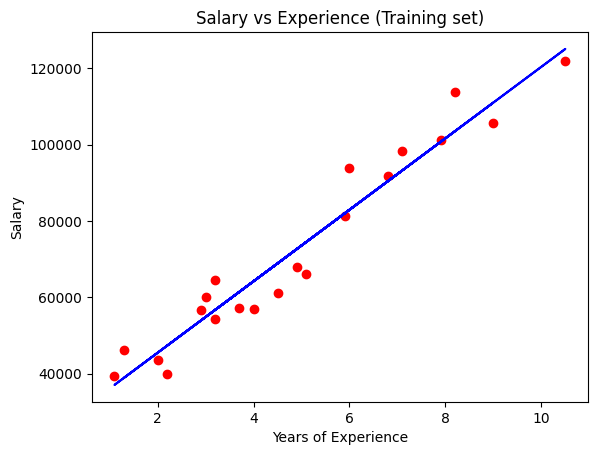

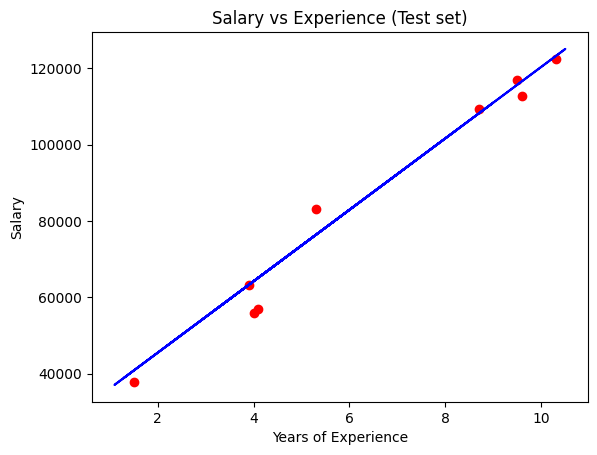

In [ ]:
# Visualising the Training set results
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

# Visualising the Test set results
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

[범죄율로 집 값 예측하기](https://www.codeit.kr/topics/elementary-supervised-algorithms/lessons/3086)

In [ ]:
# 보스턴 집 데이터로 단순 선형 회귀 (범죄율 → 집값)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

boston_df = pd.read_csv("./dataset/boston.csv")

X = boston_df[['CRIM']]  # 범죄율 열만 사용
y = boston_df['target']

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# 모델 학습 및 예측
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

y_test_predict = linear_regression_model.predict(X_test)

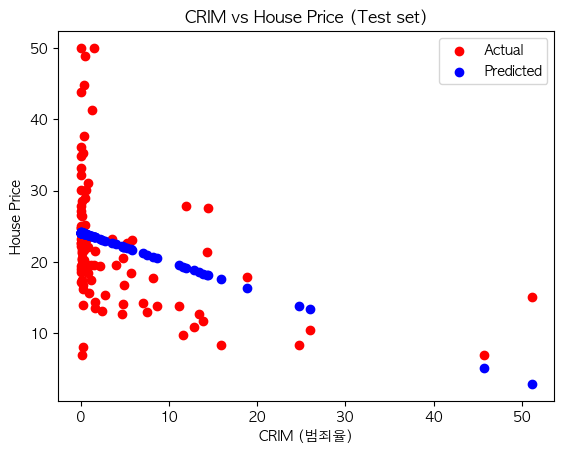

In [ ]:
# 테스트 데이터에 대한 예측값 시각화

plt.scatter(X_test, y_test, color='red', label='Actual')
plt.scatter(X_test, y_test_predict, color='blue', label='Predicted')
plt.title('CRIM vs House Price (Test set)')
plt.xlabel('CRIM (범죄율)')
plt.ylabel('House Price')
plt.legend()
plt.show()
